# Baseline Mondrian METEP - SiSU 2016

**Trabalho Final METEP** | Linha de Base Estática de K-Anonimato

---

Este notebook implementa e documenta a **linha de base estática** do experimento de privacidade sobre os dados do SiSU 2016, seguindo a metodologia do trabalho:

1. **Carregamento dos dados** - primeiras 1.000 linhas dos dois recortes temporais (T1: 1ª Chamada, T2: 2ª Chamada)
2. **Classificação semântica** dos atributos em QI / SD / Secundários Dinâmicos
3. **Implementação do Basic Mondrian** (Python 3, adaptado de `Basic_Mondrian/mondrian.py`)
4. **Avaliação da qualidade** - NCP, distribuição de partições, trade-off privacidade vs. utilidade
5. **Modelação de ataques de inferência** - Algébrico, Lógico Intratabela, Cross-Release Temporal

---
## Secção 0 - Configuração do Ambiente

O `Basic_Mondrian` foi escrito em **Python 2** (usa `print "..."`, `.sort(cmp=...)`, `dict.keys()` sem `list()`). Aqui importamos apenas os modelos de dados (`GenTree`, `NumRange`) e reimplementamos as funções centrais do Mondrian em Python 3 na Secção 4.

In [1]:
import sys, os, functools, time, warnings, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, HTML

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams.update({'font.size': 11, 'figure.dpi': 100})

# --- Adicionar Basic_Mondrian/models ao sys.path ---
MONDRIAN_DIR = os.path.join(os.getcwd(), 'Basic_Mondrian')
if MONDRIAN_DIR not in sys.path:
    sys.path.insert(0, MONDRIAN_DIR)

from models.gentree import GenTree
from models.numrange import NumRange

print('Ambiente configurado')
print(f'  Python : {sys.version.split()[0]}')
print(f'  Pandas : {pd.__version__}')
print(f'  NumPy  : {np.__version__}')
print(f'  Basic_Mondrian path: {MONDRIAN_DIR}')

Ambiente configurado
  Python : 3.10.11
  Pandas : 2.1.4
  NumPy  : 1.26.4
  Basic_Mondrian path: c:\Users\joao_\OneDrive\Área de Trabalho\metep-trabalho-final\Basic_Mondrian


---
## Secção 1 - Carregamento dos Dados (SiSU 2016)

Usamos os dois recortes temporais do SiSU 2016, chamada regular:

| Recorte | Arquivo | Descrição |
|---------|---------|----------|
| **T1** | `relatorio_chamada_regular_SISU_2016_1.csv` | 1ª Chamada - candidatos com nota mais alta |
| **T2** | `relatorio_chamada_regular_SISU_2016_2.csv` | 2ª Chamada - vagas de quem recusou T1, nota de corte menor |

**Formato**: separador `|`, decimal `,` (padrão brasileiro), encoding UTF-8.

> Limitamos a **1.000 linhas** por arquivo para fins experimentais.

### Download automático dos dados

Se os arquivos CSV ainda não estiverem presentes em , a célula abaixo acede ao portal **dadosabertos.mec.gov.br**, extrai o link direto de download e salva os ficheiros localmente.

Mesma lógica de scraping do  — usa apenas a stdlib (, ).

Se o download falhar (portal fora do ar ou bloqueio de rede), a célula imprime o URL manual e o restante do notebook continua normalmente com os ficheiros já existentes.

In [ ]:
import urllib.request
import urllib.parse
import html.parser
from pathlib import Path

DATA_DIR = 'experimental_base'

# Links do portal MEC para os dois recortes SiSU 2016
_ARQUIVOS_2016 = [
    ('https://dadosabertos.mec.gov.br/sisu/item/214-2016-relatorio-sisu-chamada-regular-1-2016',
     'relatorio_chamada_regular_SISU_2016_1.csv'),
    ('https://dadosabertos.mec.gov.br/sisu/item/213-2016-relatorio-sisu-chamada-regular-2-2016',
     'relatorio_chamada_regular_SISU_2016_2.csv'),
]

_UA   = 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
_EXTS = ('.csv', '.zip', '.xlsx', '.xls', '.csv.zip')


class _LinkParser(html.parser.HTMLParser):
    """Extrai link direto de download a partir da página do portal MEC."""
    def __init__(self, base_url):
        super().__init__()
        self.base_url = base_url
        self.links = []

    def handle_starttag(self, tag, attrs):
        if tag != 'a':
            return
        href = dict(attrs).get('href', '') or ''
        low = href.lower()
        if any(low.endswith(e) for e in _EXTS) or 'download' in low:
            self.links.append(urllib.parse.urljoin(self.base_url, href))


def _get_direct_link(portal_url):
    """Faz scraping da página do portal e devolve o URL direto do arquivo."""
    try:
        req = urllib.request.Request(portal_url, headers={'User-Agent': _UA})
        with urllib.request.urlopen(req, timeout=30) as r:
            html_text = r.read().decode('utf-8', errors='replace')
        parser = _LinkParser(portal_url)
        parser.feed(html_text)
        return parser.links[0] if parser.links else None
    except Exception as exc:
        print(f'  aviso: nao foi possivel acessar o portal: {exc}')
        return None


def _download(url, dest):
    """Baixa  para . Devolve True se bem-sucedido."""
    dest = Path(dest)
    dest.parent.mkdir(parents=True, exist_ok=True)
    print(f'  baixando {dest.name} ...', end=' ', flush=True)
    try:
        req = urllib.request.Request(url, headers={'User-Agent': _UA})
        with urllib.request.urlopen(req, timeout=300) as r:
            data = r.read()
        dest.write_bytes(data)
        print(f'OK  ({dest.stat().st_size / 1e6:.0f} MB)')
        return True
    except Exception as exc:
        print(f'ERRO: {exc}')
        if dest.exists():
            dest.unlink()
        return False


# --- Verificar existência e baixar se necessário ---
data_path = Path(DATA_DIR)
data_path.mkdir(exist_ok=True)

print('Verificando arquivos SiSU 2016 ...')
for portal_url, filename in _ARQUIVOS_2016:
    dest = data_path / filename
    if dest.exists() and dest.stat().st_size > 0:
        print(f'  ok (já existe)  {filename}  ({dest.stat().st_size / 1e6:.0f} MB)')
    else:
        print(f'  procurando link direto para {filename} ...')
        direct_url = _get_direct_link(portal_url)
        if direct_url:
            _download(direct_url, dest)
        else:
            print(f'  DOWNLOAD MANUAL: {portal_url}')
print('Verificação concluída.')

In [3]:
DATA_DIR = 'experimental_base'
NROWS    = 1000

def carregar_sisu(nome_arquivo, nrows=NROWS):
    caminho = os.path.join(DATA_DIR, nome_arquivo)
    return pd.read_csv(
        caminho, sep='|', nrows=nrows,
        encoding='utf-8', decimal=',', low_memory=False
    )

t1_raw = carregar_sisu('relatorio_chamada_regular_SISU_2016_1.csv')
t2_raw = carregar_sisu('relatorio_chamada_regular_SISU_2016_2.csv')

print(f'T1 - 1ª Chamada: {len(t1_raw):,} registros x {t1_raw.shape[1]} colunas')
print(f'T2 - 2ª Chamada: {len(t2_raw):,} registros x {t2_raw.shape[1]} colunas')
print()
print('Primeiras colunas disponíveis:')
print(list(t1_raw.columns[:10]), '...')

T1 - 1ª Chamada: 1,000 registros x 52 colunas
T2 - 2ª Chamada: 1,000 registros x 53 colunas

Primeiras colunas disponíveis:
['nu_ano', 'nu_edicao', 'ds_etapa', 'cod_ies', 'ies', 'sigla_ies', 'uf_ies', 'cod_campus', 'campus', 'uf_campus'] ...


In [4]:
# Inspecionar campos-chave
COLS_SHOW = ['tp_sexo','dt_nascimento','uf_origem','grau','turno',
             'nu_nota_l','nu_nota_ch','nu_nota_cn','nu_nota_m','nu_nota_r',
             'nu_peso_l','nu_peso_m','nu_peso_r',
             'nota_concorrencia','nu_notacorte','st_aprovado','st_matricula']

print('=== AMOSTRA T1 (3 primeiros registros) ===')
display(t1_raw[COLS_SHOW].head(3))

print('\n=== VALORES NULOS POR COLUNA (T1) ===')
nulos = t1_raw[COLS_SHOW].isnull().sum()
print(nulos[nulos > 0].to_string() if nulos.any() else 'Nenhum valor nulo nas colunas-chave')

=== AMOSTRA T1 (3 primeiros registros) ===


,tp_sexo,dt_nascimento,uf_origem,grau,turno,nu_nota_l,nu_nota_ch,nu_nota_cn,nu_nota_m,nu_nota_r,nu_peso_l,nu_peso_m,nu_peso_r,nota_concorrencia,nu_notacorte,st_aprovado,st_matricula
0,F,26/12/1996,RJ,Bacharelado,Integral,663.20,724.70,694.20,799.50,920.00,1.00,1.00,1.00,760.32,701.28,S,EFETIVADA
1,F,28/03/1992,SP,Tecnológico,Noturno,563.10,613.80,476.00,503.70,560.00,1.00,2.00,2.00,540.04,700.86,N,NÃO MATRICULADO
2,F,28/03/1992,SP,Tecnológico,Noturno,563.10,613.80,476.00,503.70,560.00,3.00,3.00,2.00,541.02,654.91,N,NÃO MATRICULADO



=== VALORES NULOS POR COLUNA (T1) ===
Nenhum valor nulo nas colunas-chave


---
## Secção 2 - Classificação Semântica dos Atributos

Classificamos os 52 atributos em três categorias com base no seu papel privacidade:

| Categoria | Definição | Ação no Mondrian |
|-----------|-----------|------------------|
| **QI** (Quasi-Identificadores) | Atributos não-sensíveis que, combinados, podem re-identificar o indivíduo | **Generalizados** (suprimidos até k-anonimato) |
| **SD** (Dados Sensíveis) | Informações que o titular quer proteger | **Preservados** (é o SA no Mondrian) |
| **Secundários Dinâmicos** | Atributos que variam entre lançamentos - vetores de ataque | Publicados, mas explorados pelos ataques |

In [5]:
grupos = {
    'Quasi-Identificadores (QI)': [
        ('tp_sexo',       'Sexo do candidato (M/F)',            'Binário; discrimina metade da pop. — alto poder de cruzamento'),
        ('dt_nascimento', 'Data de nascimento → Idade',         'Contínua; derivamos faixa etária (2016 - ano)'),
        ('uf_origem',     'UF de residência',                   '27 estados → hierarquia regional → *'),
        ('grau',          'Grau do curso',                      'Bacharelado / Tecnológico / Licenciatura'),
        ('turno',         'Turno do curso',                     'Integral / Noturno / Matutino / Vespertino'),
    ],
    'Dados Sensíveis (SD)': [
        ('st_aprovado',   'Aprovado? (S/N)',                    'Revela desempenho — protegido como SA no Mondrian'),
        ('st_matricula',  'Matriculado? (EFETIVADA/NAO MATR.)',  'Decisão educacional privada — nosso SA principal'),
    ],
    'Atributos Secundários Dinâmicos': [
        ('nota_concorrencia', 'Nota final ponderada',           'Varia entre chamadas; alvo da inferência algébrica e lógica'),
        ('nu_notacorte',      'Nota de corte do curso/chamada', 'Pública por curso; habilita o ataque lógico intratabela'),
        ('nu_classificacao',  'Posição no ranking',             'Identificador de facto em cursos pequenos'),
        ('nu_nota_l/ch/cn/m/r','Notas ENEM por componente',    'Com pesos nu_peso_x, permitem reconstrução algébrica exata'),
    ]
}

for cat, attrs in grupos.items():
    print(f'\n{"="*72}')
    print(f'  {cat}')
    print(f'{"="*72}')
    for col, label, just in attrs:
        print(f'  {col:<22} {label:<32}  {just}')


  Quasi-Identificadores (QI)
  tp_sexo                Sexo do candidato (M/F)           Binário; discrimina metade da pop. — alto poder de cruzamento
  dt_nascimento          Data de nascimento → Idade        Contínua; derivamos faixa etária (2016 - ano)
  uf_origem              UF de residência                  27 estados → hierarquia regional → *
  grau                   Grau do curso                     Bacharelado / Tecnológico / Licenciatura
  turno                  Turno do curso                    Integral / Noturno / Matutino / Vespertino

  Dados Sensíveis (SD)
  st_aprovado            Aprovado? (S/N)                   Revela desempenho — protegido como SA no Mondrian
  st_matricula           Matriculado? (EFETIVADA/NAO MATR.)  Decisão educacional privada — nosso SA principal

  Atributos Secundários Dinâmicos
  nota_concorrencia      Nota final ponderada              Varia entre chamadas; alvo da inferência algébrica e lógica
  nu_notacorte           Nota de corte do curso/c

---
## Secção 3 - Pré-processamento para o Mondrian

O Basic Mondrian requer que:
- **Todos os valores sejam strings** (inclusive numéricos)
- **Atributos numéricos** sejam registados num `NumRange` (lista ordenada de valores únicos)
- **Atributos categóricos** sejam registados num `GenTree` (árvore de hierarquia de generalização)

Etapas:
1. Derivar `idade` a partir de `dt_nascimento`
2. Agrupar `nota_concorrencia` em intervalos de 10 pontos (reduz cardinalidade sem perder sentido)
3. Normalizar UFs para as 27 estados reconhecidos

In [6]:
# Mapeamento UF → Região geográfica (hierarquia de generalização)
UF_REGIAO = {
    'AC':'Norte','AM':'Norte','AP':'Norte','PA':'Norte','RO':'Norte','RR':'Norte','TO':'Norte',
    'AL':'Nordeste','BA':'Nordeste','CE':'Nordeste','MA':'Nordeste',
    'PB':'Nordeste','PE':'Nordeste','PI':'Nordeste','RN':'Nordeste','SE':'Nordeste',
    'DF':'Centro-Oeste','GO':'Centro-Oeste','MS':'Centro-Oeste','MT':'Centro-Oeste',
    'ES':'Sudeste','MG':'Sudeste','RJ':'Sudeste','SP':'Sudeste',
    'PR':'Sul','RS':'Sul','SC':'Sul'
}

def extrair_idade(dt_nasc, ano_ref=2016):
    try:
        return ano_ref - int(str(dt_nasc).split('/')[-1])
    except:
        return None

def preprocessar(df):
    out = df.copy()
    out['idade'] = out['dt_nascimento'].apply(extrair_idade)
    # UFs desconhecidas → 'Outros'
    out['uf_origem'] = out['uf_origem'].where(out['uf_origem'].isin(UF_REGIAO), other='Outros')
    # Nota em intervalos de 10 pontos (reduz cardinalidade)
    out['nota_bucket'] = out['nota_concorrencia'].apply(
        lambda x: int(float(x) // 10) * 10 if pd.notna(x) else None
    )
    return out

t1 = preprocessar(t1_raw)
t2 = preprocessar(t2_raw)

print('Estatísticas após pré-processamento:')
print(f'\n{"":20s}{"T1 (1ª Chamada)":>18s}{"T2 (2ª Chamada)":>18s}')
print(f'{"Registros":<20}{len(t1):>18,}{len(t2):>18,}')
print(f'{"Idade média":<20}{t1["idade"].mean():>18.1f}{t2["idade"].mean():>18.1f}')
print(f'{"Sexo F (%)":<20}{(t1["tp_sexo"]=="F").mean()*100:>18.1f}{(t2["tp_sexo"]=="F").mean()*100:>18.1f}')
print(f'{"Aprovados (%)":<20}{(t1["st_aprovado"]=="S").mean()*100:>18.1f}{(t2["st_aprovado"]=="S").mean()*100:>18.1f}')
print(f'{"Matriculados (%)":<20}{(t1["st_matricula"]=="EFETIVADA").mean()*100:>18.1f}{(t2["st_matricula"]=="EFETIVADA").mean()*100:>18.1f}')
print(f'{"Nota média":<20}{t1["nota_concorrencia"].mean():>18.1f}{t2["nota_concorrencia"].mean():>18.1f}')

Estatísticas após pré-processamento:

                       T1 (1ª Chamada)   T2 (2ª Chamada)
Registros                        1,000             1,000
Idade média                       23.9              23.9
Sexo F (%)                        56.3              57.1
Aprovados (%)                      6.5               4.2
Matriculados (%)                   3.3               0.0
Nota média                       558.7             565.7


---
## Secção 4 - Implementação do Basic Mondrian (Python 3)

### Como funciona o Basic Mondrian

O algoritmo é um **particionamento top-down guloso** sobre o espaço multi-dimensional dos QIs:

```
Partição Inteira (todos os N registros)
         │
         ▼  choose_dimension() - escolhe a dimensão de maior largura normalizada
   split_numerical() ou split_categorical()
         │
    ┌────┴────┐
    ▼         ▼
  Sub-L    Sub-R    (cada sub-partição tem ≥ k registros)
    │         │
  recursão  recursão
    │         │
    ▼         ▼
  RESULT   RESULT   (quando não é mais possível dividir com |grupo| ≥ k)
```

**NCP (Normalized Certainty Penalty)** mede a perda de informação:
$$\text{NCP} = \frac{1}{|QI| \cdot N} \sum_{p \in \text{RESULT}} |p| \cdot \sum_{i=1}^{|QI|} \frac{\text{width}_i(p)}{\text{range}_i}$$

NCP = 0% → nenhuma perda | NCP = 100% → tudo generalizado para o valor raiz.

O código abaixo é uma adaptação do `Basic_Mondrian/mondrian.py` para Python 3. As diferenças são assinaladas nos comentários.

In [8]:
# ================================================================
# BASIC MONDRIAN - Python 3
# Adaptado de Basic_Mondrian/mondrian.py (LeFevre et al., 2006)
# Diferenças do original (Python 2):
#   - print() em vez de print ""
#   - functools.cmp_to_key() em vez de cmp= direto no sort()
#   - total // 2 em vez de total / 2 (divisão inteira)
#   - Encapsulado em classe para evitar variáveis globais
# ================================================================

def cmp_str(a, b):
    """Compara dois valores em string: numérico se possível, senão lexicográfico."""
    try:
        return (float(a) > float(b)) - (float(a) < float(b))
    except ValueError:
        return (a > b) - (a < b)


class Partition:
    """
    Representa um grupo de registros no processo de particionamento.

    member : lista de registros [QI_1, ..., QI_n, SA]
    width  : largura por dimensão
               numérico  → tupla (índice_low, índice_high) em sort_value
               categórico → int (número de folhas cobertas pelo nó atual)
    middle : valor generalizado atual de cada QI nesta partição
               numérico  → 'low,high' (string do intervalo)
               categórico → valor do nó na árvore (ex: 'Sudeste', '*')
    allow  : lista de flags [1/0] — 1 = dimensão ainda pode ser dividida
    """
    def __init__(self, data, width, middle, qi_len):
        self.member = list(data)
        self.width  = list(width)
        self.middle = list(middle)
        self.allow  = [1] * qi_len

    def __len__(self):
        return len(self.member)

    def __repr__(self):
        return f'Partition(n={len(self)}, middle={self.middle})'


class MondrianoSISU:
    """
    Implementação do Basic Mondrian K-Anonimato — Python 3.
    """

    def __init__(self):
        self.QI_LEN    = 0
        self.GL_K      = 0
        self.RESULT    = []
        self.ATT_TREES = []
        self.QI_RANGE  = []
        self.IS_CAT    = []

    # ---- NCP por dimensão ----------------------------------------
    def _norm_width(self, partition, i):
        """Largura normalizada da partição na dimensão i (contribuição ao NCP)."""
        if not self.IS_CAT[i]:
            lo, hi = partition.width[i]
            w = float(self.ATT_TREES[i].sort_value[hi]) - float(self.ATT_TREES[i].sort_value[lo])
        else:
            w = partition.width[i]
        return w / self.QI_RANGE[i]

    # ---- Escolha da dimensão de corte ----------------------------
    def _choose_dim(self, partition):
        """Seleciona a dimensão com maior largura normalizada (heurística Mondrian)."""
        best_w, best_i = -1, -1
        for i in range(self.QI_LEN):
            if partition.allow[i] == 0:
                continue
            nw = self._norm_width(partition, i)
            if nw > best_w:
                best_w, best_i = nw, i
        return best_i

    # ---- Auxiliares numéricos ------------------------------------
    def _freq_set(self, partition, dim):
        freq = {}
        for rec in partition.member:
            freq[rec[dim]] = freq.get(rec[dim], 0) + 1
        return freq

    def _find_median(self, partition, dim):
        freq  = self._freq_set(partition, dim)
        # Python 2 original: value_list.sort(cmp=cmp_str)
        vals  = sorted(freq.keys(), key=functools.cmp_to_key(cmp_str))
        total = sum(freq.values())
        mid   = total // 2          # Python 2 usava /  (divisão inteira implícita)
        if mid < self.GL_K or len(vals) <= 1:
            return ('', '', vals[0], vals[-1])
        acc, si, sv = 0, 0, ''
        for i, v in enumerate(vals):
            acc += freq[v]
            if acc >= mid:
                sv, si = v, i
                break
        nv = vals[si + 1] if si + 1 < len(vals) else sv
        return (sv, nv, vals[0], vals[-1])

    @staticmethod
    def _split_num_val(nv_str, split_at):
        parts = nv_str.split(',')
        if len(parts) <= 1:
            return parts[0], parts[0]
        lo, hi = parts[0], parts[1]
        lv = lo if lo == split_at else lo + ',' + split_at
        rv = hi if hi == split_at else split_at + ',' + hi
        return lv, rv

    # ---- Divisão numérica (corte pela mediana) -------------------
    def _split_numerical(self, partition, dim, pw, pm):
        """
        Divide a partição no atributo numérico `dim`.
        Ponto de corte = mediana → sub-partições [min,med] e (med,max].
        """
        sv, nv, lo, hi = self._find_median(partition, dim)
        p_lo = self.ATT_TREES[dim].dict[lo]
        p_hi = self.ATT_TREES[dim].dict[hi]
        pm[dim] = lo if lo == hi else lo + ',' + hi
        pw[dim] = (p_lo, p_hi)
        if sv == '' or sv == nv:
            return []
        mid_pos = self.ATT_TREES[dim].dict[sv]
        lm, rm  = pm[:], pm[:]
        lm[dim], rm[dim] = self._split_num_val(pm[dim], sv)
        lhs, rhs = [], []
        for rec in partition.member:
            if self.ATT_TREES[dim].dict[rec[dim]] <= mid_pos:
                lhs.append(rec)
            else:
                rhs.append(rec)
        lw, rw = pw[:], pw[:]
        lw[dim] = (pw[dim][0], mid_pos)
        rw[dim] = (self.ATT_TREES[dim].dict[nv], pw[dim][1])
        return [Partition(lhs, lw, lm, self.QI_LEN),
                Partition(rhs, rw, rm, self.QI_LEN)]

    # ---- Divisão categórica (por hierarquia GenTree) --------------
    def _split_categorical(self, partition, dim, pw, pm):
        """
        Divide a partição no atributo categórico `dim`.
        Usa a GenTree: desce um nível na hierarquia e distribui registros
        pelos filhos do nó atual, SE todos os grupos resultantes tiverem >= k.
        """
        node      = self.ATT_TREES[dim][partition.middle[dim]]
        sub_nodes = list(node.child)
        if not sub_nodes:
            return []
        groups = [[] for _ in sub_nodes]
        for rec in partition.member:
            for i, sn in enumerate(sub_nodes):
                if rec[dim] in sn.cover:
                    groups[i].append(rec)
                    break
        # Regra k-anonimato: qualquer sub-grupo não-vazio deve ter >= k
        if any(0 < len(g) < self.GL_K for g in groups):
            return []
        result = []
        for i, grp in enumerate(groups):
            if not grp:
                continue
            wt = pw[:]
            mt = pm[:]
            wt[dim] = len(sub_nodes[i])    # nº folhas cobertas pelo sub-nó
            mt[dim] = sub_nodes[i].value   # rótulo do sub-nó
            result.append(Partition(grp, wt, mt, self.QI_LEN))
        return result

    # ---- Recursão principal --------------------------------------
    def _anonymize(self, partition):
        """
        Passo central do Mondrian:
        1. Se não é possível dividir → adiciona a RESULT (partição final)
        2. Caso contrário → escolhe dimensão, divide, recursa nos filhos
        """
        if sum(partition.allow) == 0:
            self.RESULT.append(partition)
            return
        dim = self._choose_dim(partition)
        pw  = partition.width[:]
        pm  = partition.middle[:]
        if not self.IS_CAT[dim]:
            subs = self._split_numerical(partition, dim, pw, pm)
        else:
            subs = self._split_categorical(partition, dim, pw, pm)
        if not subs:
            partition.allow[dim] = 0   # marca dimensão como não-divisível
            self._anonymize(partition)
        else:
            for sp in subs:
                self._anonymize(sp)

    # ---- Ponto de entrada público --------------------------------
    def anonymize(self, att_trees, data, k, QI_num=-1):
        """
        Aplica k-anonimato Basic Mondrian.

        Parâmetros:
            att_trees : lista [GenTree | NumRange] para cada QI
            data      : lista de listas [QI_1, ..., QI_n, SA]  (todos strings)
            k         : parâmetro k-anonimato
            QI_num    : número de QIs (padrão: len(registro)-1)

        Retorna:
            (registros_anonimizados, ncp_pct, tempo_s, lista_particoes)
        """
        self.ATT_TREES = att_trees
        self.IS_CAT    = [not isinstance(t, NumRange) for t in att_trees]
        self.QI_LEN    = (len(data[0]) - 1) if QI_num <= 0 else QI_num
        self.GL_K      = k
        self.RESULT    = []
        self.QI_RANGE  = []

        wtemp  = []
        middle = []
        for i in range(self.QI_LEN):
            if not self.IS_CAT[i]:
                self.QI_RANGE.append(att_trees[i].range)
                wtemp.append((0, len(att_trees[i].sort_value) - 1))
                middle.append(att_trees[i].value)
            else:
                self.QI_RANGE.append(len(att_trees[i]['*']))
                wtemp.append(len(att_trees[i]['*']))
                middle.append('*')

        whole = Partition(data, wtemp, middle, self.QI_LEN)
        t0    = time.time()
        self._anonymize(whole)
        elapsed = time.time() - t0

        result, ncp = [], 0.0
        for part in self.RESULT:
            r_ncp = sum(self._norm_width(part, i) for i in range(self.QI_LEN))
            for rec in part.member:
                result.append(part.middle[:] + [rec[-1]])
            ncp += r_ncp * len(part)

        ncp = (ncp / self.QI_LEN / len(data)) * 100
        return result, ncp, elapsed, list(self.RESULT)


print('MondrianoSISU definido - pronto para uso')

MondrianoSISU definido - pronto para uso


---
## Secção 5 - Hierarquias de Generalização para o SiSU

Cada QI precisa de uma árvore de generalização:

| QI | Tipo | Hierarquia |
|----|------|------------|
| `tp_sexo` | Categórico | `*` → `F`, `M` (2 folhas) |
| `idade` | Numérico | `NumRange` com valores únicos ordenados |
| `uf_origem` | Categórico | `*` → Região (5) → UF (27) |
| `grau` | Categórico | `*` → valores únicos |
| `turno` | Categórico | `*` → valores únicos |
| `nota_bucket` | Numérico | `NumRange` de intervalos de 10 pontos |

In [10]:
def build_binary_gentree(values):
    """Hierarquia 2 níveis: '*' → valores únicos (folhas)."""
    tree = {}
    root = GenTree('*')
    tree['*'] = root
    vals_unicos = sorted(set(str(v) for v in values if pd.notna(v)))
    for v in vals_unicos:
        node = GenTree(v, parent=root, isleaf=True)
        tree[v] = node
    return tree


def build_uf_gentree(uf_values, uf_regiao_map):
    """
    Hierarquia 3 níveis: '*' → Região → UF
    Qualquer UF não reconhecida vai para nó 'Outros'.
    """
    tree = {}
    root = GenTree('*')
    tree['*'] = root
    regioes    = {}
    ufs        = set(str(v) for v in uf_values if pd.notna(v))
    # Criar nós de região
    for uf in ufs:
        reg = uf_regiao_map.get(uf, 'Outros')
        if reg not in regioes:
            rn = GenTree(reg, parent=root)
            tree[reg]   = rn
            regioes[reg] = rn
    # Criar nós folha (UF)
    for uf in ufs:
        reg  = uf_regiao_map.get(uf, 'Outros')
        node = GenTree(uf, parent=regioes[reg], isleaf=True)
        tree[uf] = node
    return tree


def build_numrange(series_int):
    """NumRange para série numérica inteira - todos os valores únicos como strings."""
    vals = sorted(set(int(v) for v in series_int.dropna()))
    if not vals:
        raise ValueError('Serie vazia para NumRange')
    vals_str = [str(v) for v in vals]
    support  = {}
    for vs, vn in zip(vals_str, vals):
        support[vs] = int((series_int == vn).sum())
    return NumRange(vals_str, support)


# Construir hierarquias com dados combinados T1 + T2
df_all = pd.concat([t1, t2], ignore_index=True)

att_trees_base = [
    build_binary_gentree(df_all['tp_sexo'].dropna()),          # 0 - sexo (cat)
    build_numrange(df_all['idade'].dropna()),                    # 1 - idade (num)
    build_uf_gentree(df_all['uf_origem'].dropna(), UF_REGIAO),  # 2 - UF   (cat)
    build_binary_gentree(df_all['grau'].dropna()),              # 3 - grau  (cat)
    build_binary_gentree(df_all['turno'].dropna()),             # 4 - turno (cat)
]

# Hierarquia estendida: inclui nota_bucket como QI adicional
att_trees_ext = att_trees_base + [
    build_numrange(df_all['nota_bucket'].dropna()),             # 5 - nota  (num)
]

print('Hierarquias construídas:')
print(f'  tp_sexo     : {len(att_trees_base[0]["*"])} folhas → {sorted(k for k in att_trees_base[0] if k!="*")}')
print(f'  idade       : {len(att_trees_base[1].sort_value)} valores ({att_trees_base[1].sort_value[0]}-{att_trees_base[1].sort_value[-1]})')
regioes_uf = set(UF_REGIAO.values())
print(f'  uf_origem   : {len(att_trees_base[2]["*"])} folhas em {len(regioes_uf)} regiões')
print(f'  grau        : {len(att_trees_base[3]["*"])} folhas → {sorted(k for k in att_trees_base[3] if k!="*")}')
print(f'  turno       : {len(att_trees_base[4]["*"])} folhas → {sorted(k for k in att_trees_base[4] if k!="*")}')
print(f'  nota_bucket : {len(att_trees_ext[5].sort_value)} valores ({att_trees_ext[5].sort_value[0]}-{att_trees_ext[5].sort_value[-1]})')

Hierarquias construídas:
  tp_sexo     : 2 folhas → ['F', 'M']
  idade       : 41 valores (15-60)
  uf_origem   : 26 folhas em 5 regiões
  grau        : 4 folhas → ['Bacharelado', 'Licenciatura', 'Tecnológico', 'Área Básica de Ingresso (ABI)']
  turno       : 4 folhas → ['Integral', 'Matutino', 'Noturno', 'Vespertino']
  nota_bucket : 44 valores (290-790)


---
## Secção 6 - Aplicação do Basic Mondrian (T1 e T2 independentes)

O Mondrian é aplicado **separadamente** sobre T1 e T2 - esta é a limitação fundamental da linha de base estática que os ataques explorarão.

Testamos com `k ∈ {2, 5, 10, 25}` para observar o trade-off NCP × privacidade.

In [11]:
def preparar_registros(df, cols_qi, col_sa, col_nota=None):
    """
    Converte DataFrame em lista de listas [QI..., SA] (todos strings).
    Se col_nota != None, inclui nota_bucket como QI adicional.
    O SA pode ser uma string composta 'matricula|nota_orig|notacorte'
    para uso nos ataques (passada por dentro sem ser anonimizada).
    """
    colunas = cols_qi[:]
    if col_nota:
        colunas.append(col_nota)
    filtro = df.dropna(subset=colunas + [col_sa]).copy()
    registros = []
    for _, row in filtro.iterrows():
        rec = []
        for c in colunas:
            if c in ('idade', 'nota_bucket'):
                rec.append(str(int(row[c])))
            else:
                rec.append(str(row[c]))
        rec.append(str(row[col_sa]))   # SA - não anonimizado
        registros.append(rec)
    return registros


COLS_QI_BASE = ['tp_sexo', 'idade', 'uf_origem', 'grau', 'turno']
COL_SA       = 'st_matricula'

dados_t1_base = preparar_registros(t1, COLS_QI_BASE, COL_SA)
dados_t2_base = preparar_registros(t2, COLS_QI_BASE, COL_SA)

print(f'Registros T1 (base): {len(dados_t1_base)}')
print(f'Registros T2 (base): {len(dados_t2_base)}')
print()
print('Exemplo de registro (T1):')
print('  QIs:', dados_t1_base[0][:-1])
print('  SA :', dados_t1_base[0][-1])

Registros T1 (base): 1000
Registros T2 (base): 1000

Exemplo de registro (T1):
  QIs: ['F', '20', 'RJ', 'Bacharelado', 'Integral']
  SA : EFETIVADA


In [12]:
mondrian = MondrianoSISU()
K_VALORES = [2, 5, 10, 25]
resultados = {}

print(f'{"k":>4}  {"NCP T1":>8}  {"NCP T2":>8}  {"Parts T1":>9}  {"Parts T2":>9}  {"Tempo T1":>8}  {"Tempo T2":>8}')
print('-' * 65)

for k in K_VALORES:
    anon_t1, ncp_t1, t_t1, parts_t1 = mondrian.anonymize(att_trees_base, dados_t1_base, k)
    anon_t2, ncp_t2, t_t2, parts_t2 = mondrian.anonymize(att_trees_base, dados_t2_base, k)
    resultados[k] = {
        'ncp_t1':ncp_t1, 'ncp_t2':ncp_t2,
        'tempo_t1':t_t1, 'tempo_t2':t_t2,
        'nparts_t1':len(parts_t1), 'nparts_t2':len(parts_t2),
        'anon_t1':anon_t1, 'anon_t2':anon_t2,
        'parts_t1':parts_t1, 'parts_t2':parts_t2,
    }
    print(f'{k:>4}  {ncp_t1:>7.2f}%  {ncp_t2:>7.2f}%  {len(parts_t1):>9}  {len(parts_t2):>9}  {t_t1:>7.3f}s  {t_t2:>7.3f}s')

print('\n* NCP: quanto menor, melhor (menor perda de informação)')
print('* Mais partições → generalização mais fina (melhor utilidade, mas mais risco)')

   k    NCP T1    NCP T2   Parts T1   Parts T2  Tempo T1  Tempo T2
-----------------------------------------------------------------
   2     8.45%     7.91%        329        315    0.014s    0.013s
   5    31.36%    26.68%        120        126    0.003s    0.012s
  10    44.04%    41.99%         57         55    0.006s    0.000s
  25    61.13%    56.49%         19         20    0.010s    0.000s

* NCP: quanto menor, melhor (menor perda de informação)
* Mais partições → generalização mais fina (melhor utilidade, mas mais risco)


---
## Secção 7 - Avaliação da Qualidade da Anonimização

Analisamos: NCP ao longo de k, distribuição de tamanhos de partição, e exemplos concretos de generalização.

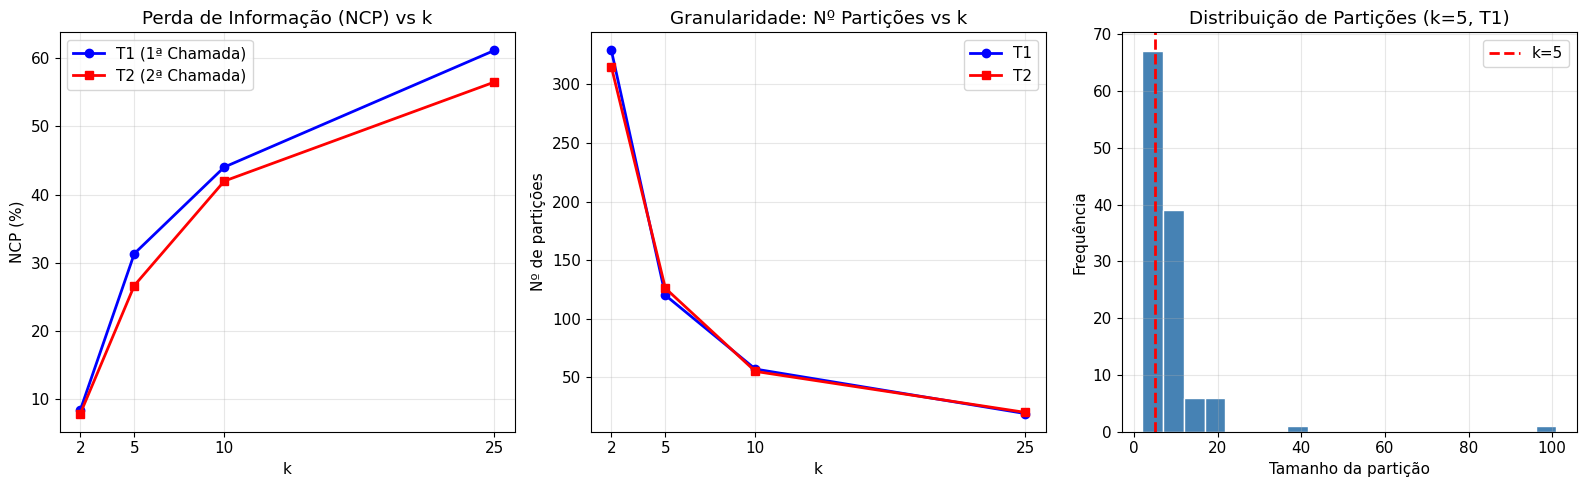

k=5: 120 partições | tamanho mín=2, máx=101, mediana=6


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. NCP vs k
ncp_t1 = [resultados[k]['ncp_t1'] for k in K_VALORES]
ncp_t2 = [resultados[k]['ncp_t2'] for k in K_VALORES]
axes[0].plot(K_VALORES, ncp_t1, 'b-o', lw=2, label='T1 (1ª Chamada)')
axes[0].plot(K_VALORES, ncp_t2, 'r-s', lw=2, label='T2 (2ª Chamada)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('NCP (%)')
axes[0].set_title('Perda de Informação (NCP) vs k')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(K_VALORES)

# 2. Nº partições vs k
np_t1 = [resultados[k]['nparts_t1'] for k in K_VALORES]
np_t2 = [resultados[k]['nparts_t2'] for k in K_VALORES]
axes[1].plot(K_VALORES, np_t1, 'b-o', lw=2, label='T1')
axes[1].plot(K_VALORES, np_t2, 'r-s', lw=2, label='T2')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Nº de partições')
axes[1].set_title('Granularidade: Nº Partições vs k')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(K_VALORES)

# 3. Distribuição de tamanho das partições (k=5, T1)
k_ref   = 5
parts   = resultados[k_ref]['parts_t1']
tamanhos = [len(p) for p in parts]
axes[2].hist(tamanhos, bins=20, color='steelblue', edgecolor='white')
axes[2].axvline(k_ref, color='red', ls='--', lw=2, label=f'k={k_ref}')
axes[2].set_xlabel('Tamanho da partição')
axes[2].set_ylabel('Frequência')
axes[2].set_title(f'Distribuição de Partições (k={k_ref}, T1)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'k={k_ref}: {len(parts)} partições | tamanho mín={min(tamanhos)}, máx={max(tamanhos)}, mediana={np.median(tamanhos):.0f}')

In [14]:
# Comparação antes / depois (k=5, T1)
k_ref = 5
print('=== ANTES: registros originais (T1, primeiros 5) ===')
for i, rec in enumerate(dados_t1_base[:5]):
    print(f'  [{i}] tp_sexo={rec[0]}  idade={rec[1]}  uf={rec[2]}  grau={rec[3]}  turno={rec[4]}  SA={rec[5]}')

print()
print(f'=== DEPOIS: registros anonimizados (k={k_ref}, T1, primeiros 5) ===')
for i, rec in enumerate(resultados[k_ref]['anon_t1'][:5]):
    print(f'  [{i}] tp_sexo={rec[0]}  idade={rec[1]}  uf={rec[2]}  grau={rec[3]}  turno={rec[4]}  SA={rec[5]}')

print()
print('Legenda dos campos generalizados:')
print('  Numérico: "18,25" = intervalo [18, 25]')
print('  Categórico: "Sudeste" = generalizado para região')
print('             "*" = completamente suprimido (valor raiz)')

=== ANTES: registros originais (T1, primeiros 5) ===
  [0] tp_sexo=F  idade=20  uf=RJ  grau=Bacharelado  turno=Integral  SA=EFETIVADA
  [1] tp_sexo=F  idade=24  uf=SP  grau=Tecnológico  turno=Noturno  SA=NÃO MATRICULADO
  [2] tp_sexo=F  idade=24  uf=SP  grau=Tecnológico  turno=Noturno  SA=NÃO MATRICULADO
  [3] tp_sexo=M  idade=22  uf=PE  grau=Bacharelado  turno=Noturno  SA=NÃO MATRICULADO
  [4] tp_sexo=M  idade=22  uf=PE  grau=Bacharelado  turno=Noturno  SA=NÃO MATRICULADO

=== DEPOIS: registros anonimizados (k=5, T1, primeiros 5) ===
  [0] tp_sexo=F  idade=17,21  uf=Norte  grau=*  turno=*  SA=NÃO MATRICULADO
  [1] tp_sexo=F  idade=17,21  uf=Norte  grau=*  turno=*  SA=NÃO MATRICULADO
  [2] tp_sexo=F  idade=17,21  uf=Norte  grau=*  turno=*  SA=NÃO MATRICULADO
  [3] tp_sexo=F  idade=17,21  uf=Norte  grau=*  turno=*  SA=NÃO MATRICULADO
  [4] tp_sexo=F  idade=17,21  uf=Norte  grau=*  turno=*  SA=NÃO MATRICULADO

Legenda dos campos generalizados:
  Numérico: "18,25" = intervalo [18, 25]
  C

---
## Secção 8 - Ataques de Inferência

Demonstramos três vetores de ataque que **quebram as proteções aplicadas isoladamente** pelo Mondrian.

A linha de base estática protege cada tabela individualmente, mas não se defende de adversários que exploram dependências algébricas ou cruzamentos temporais.

### Ataque 1 - Inferência Algébrica

**Premissa**: O publisher tenta proteger `nota_concorrencia` suprimindo-a da tabela publicada. Porém, as notas por componente (`nu_nota_l/ch/cn/m/r`) e os pesos (`nu_peso_x`) permanecem publicados por exigência de transparência.

**Fórmula algébrica**:
$$\text{nota\_concorrencia} = \frac{\sum_{x \in \{L,CH,CN,M,R\}} nu\_nota_x \times nu\_peso_x}{\sum_{x} nu\_peso_x}$$

**Ataque**: O adversário recalcula `nota_concorrencia` exatamente para qualquer registro. A supressão é ineficaz.

In [15]:
NOTAS = ['nu_nota_l','nu_nota_ch','nu_nota_cn','nu_nota_m','nu_nota_r']
PESOS = ['nu_peso_l','nu_peso_ch','nu_peso_cn','nu_peso_m','nu_peso_r']

def ataque_algebrico(df, label='T1'):
    """
    Verifica que nota_concorrencia é algebricamente determinada pelas notas
    componentes e pesos — portanto, a sua supressão é ineficaz.
    """
    df_atk = df.dropna(subset=NOTAS + PESOS + ['nota_concorrencia']).copy()

    # Reconstrução algébrica
    soma_pond = (df_atk[NOTAS].values * df_atk[PESOS].values).sum(axis=1)
    soma_pesos = df_atk[PESOS].sum(axis=1)
    df_atk['nota_reconstruida'] = soma_pond / soma_pesos
    df_atk['erro_abs'] = (df_atk['nota_reconstruida'] - df_atk['nota_concorrencia']).abs()

    n_total    = len(df_atk)
    n_exatos   = (df_atk['erro_abs'] < 0.01).sum()
    n_proximos = (df_atk['erro_abs'] < 1.0).sum()
    erro_medio = df_atk['erro_abs'].mean()

    print(f'=== Ataque Algébrico — {label} ===')
    print(f'  Registros atacados        : {n_total}')
    print(f'  Nota reconstruída (err<0.01): {n_exatos}/{n_total} ({n_exatos/n_total*100:.1f}%)')
    print(f'  Nota reconstruída (err<1.0) : {n_proximos}/{n_total} ({n_proximos/n_total*100:.1f}%)')
    print(f'  Erro médio absoluto        : {erro_medio:.4f} pontos')
    print()
    print('  Exemplo (3 registros):')
    cols = ['nota_concorrencia', 'nota_reconstruida', 'erro_abs']
    print(df_atk[cols].head(3).to_string(index=False))
    return df_atk

result_atk1_t1 = ataque_algebrico(t1, 'T1')
print()
result_atk1_t2 = ataque_algebrico(t2, 'T2')

=== Ataque Algébrico — T1 ===
  Registros atacados        : 1000
  Nota reconstruída (err<0.01): 1000/1000 (100.0%)
  Nota reconstruída (err<1.0) : 1000/1000 (100.0%)
  Erro médio absoluto        : 0.0012 pontos

  Exemplo (3 registros):
 nota_concorrencia  nota_reconstruida  erro_abs
            760.32             760.32      0.00
            540.04             540.04      0.00
            541.02             541.02      0.00

=== Ataque Algébrico — T2 ===
  Registros atacados        : 1000
  Nota reconstruída (err<0.01): 1000/1000 (100.0%)
  Nota reconstruída (err<1.0) : 1000/1000 (100.0%)
  Erro médio absoluto        : 0.0014 pontos

  Exemplo (3 registros):
 nota_concorrencia  nota_reconstruida  erro_abs
            689.22             689.22      0.00
            689.22             689.22      0.00
            702.44             702.44      0.00


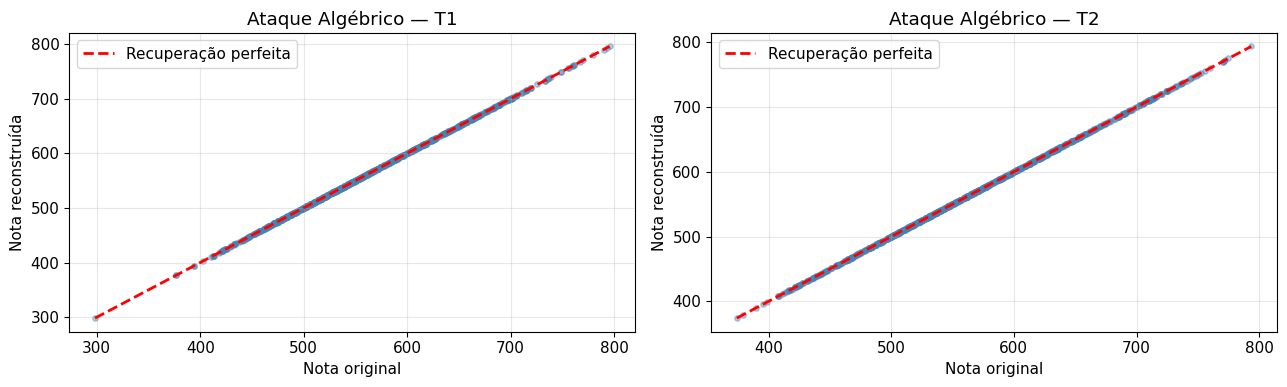

CONCLUSAO: nota_concorrencia é algebricamente determinada pelas variáveis publicadas.
Qualquer generalização sobre ela é TRIVIALMENTE reversível pelo adversário.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (res, label) in zip(axes, [(result_atk1_t1,'T1'),(result_atk1_t2,'T2')]):
    ax.scatter(res['nota_concorrencia'], res['nota_reconstruida'],
               alpha=0.4, s=15, color='steelblue')
    lim = [res['nota_concorrencia'].min(), res['nota_concorrencia'].max()]
    ax.plot(lim, lim, 'r--', lw=2, label='Recuperação perfeita')
    ax.set_xlabel('Nota original')
    ax.set_ylabel('Nota reconstruída')
    ax.set_title(f'Ataque Algébrico — {label}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('CONCLUSAO: nota_concorrencia é algebricamente determinada pelas variáveis publicadas.')
print('Qualquer generalização sobre ela é TRIVIALMENTE reversível pelo adversário.')

### Ataque 2 - Inferência Lógica Intratabela

**Premissa**: O Mondrian generaliza `nota_concorrencia` (como QI estendido) para um intervalo `[a, b]`. Mas a mesma tabela publica `st_matricula` e `nu_notacorte`.

**Restrição lógica**:
- Se `st_matricula == 'EFETIVADA'` → nota ≥ nu_notacorte → limite inferior efetivo = max(a, notacorte)
- Se `st_matricula == 'NÃO MATRICULADO'` (e não aprovado) → nota < nu_notacorte → limite superior efetivo = min(b, notacorte)

**Ataque**: A interseção do intervalo generalizado com o constraint lógico reduz o espaço de incerteza, muitas vezes de forma substancial.

In [18]:
# Aplicar Mondrian com nota_bucket como QI adicional
dados_t1_ext = preparar_registros(t1, COLS_QI_BASE, COL_SA, col_nota='nota_bucket')
dados_t2_ext = preparar_registros(t2, COLS_QI_BASE, COL_SA, col_nota='nota_bucket')

K_ATK2 = 5
anon_t1_ext, ncp_t1_ext, _, parts_t1_ext = mondrian.anonymize(att_trees_ext, dados_t1_ext, K_ATK2)
print(f'Mondrian estendido (com nota_bucket, k={K_ATK2}):')
print(f'  T1: NCP={ncp_t1_ext:.2f}%, partições={len(parts_t1_ext)}')

# Construir mapeamento: cada registro anonimizado → intervalo de nota generalizado
def parse_nota_interval(nota_str):
    """Converte '620,720' ou '680' para (lo, hi)."""
    parts = nota_str.split(',')
    lo = int(parts[0])
    hi = int(parts[-1])
    return lo, hi

# Juntar registros originais com a generalização (preservando ordem por índice)
t1_atk2 = t1.dropna(subset=COLS_QI_BASE + ['nota_bucket', 'st_matricula', 'nu_notacorte']).copy()
t1_atk2 = t1_atk2.reset_index(drop=True)

# Cada registro anonimizado tem o campo nota_bucket generalizado (índice 5)
# e o SA original (st_matricula) na posição -1
intervalos_orig  = []
intervalos_efet  = []
reducoes         = []

for orig_row, anon_rec in zip(t1_atk2.itertuples(), anon_t1_ext):
    nota_gen_str = anon_rec[5]   # campo nota generalizado
    lo, hi       = parse_nota_interval(nota_gen_str)
    intervalo_orig = hi - lo

    notacorte = float(orig_row.nu_notacorte) if pd.notna(orig_row.nu_notacorte) else None
    matricula = str(orig_row.st_matricula)

    if notacorte is None:
        efet_lo, efet_hi = lo, hi
    elif 'EFETIVADA' in matricula:
        efet_lo = max(lo, int(notacorte))
        efet_hi = hi
    else:
        efet_lo = lo
        efet_hi = min(hi, int(notacorte))

    efet_hi = max(efet_hi, efet_lo)   # garantir intervalo não-negativo
    intervalo_efet = efet_hi - efet_lo

    intervalos_orig.append(intervalo_orig)
    intervalos_efet.append(intervalo_efet)
    reducoes.append(intervalo_orig - intervalo_efet)

reducoes      = np.array(reducoes)
intervalos_orig = np.array(intervalos_orig)

print()
print(f'=== Ataque Lógico Intratabela (k={K_ATK2}, T1) ===')
print(f'  Registros analisados          : {len(reducoes)}')
print(f'  Intervalo médio (pós-Mondrian): {np.mean(intervalos_orig):.1f} pontos')
print(f'  Intervalo médio (pós-ataque)  : {np.mean(np.array(intervalos_orig) - reducoes):.1f} pontos')
print(f'  Redução média                 : {np.mean(reducoes):.1f} pontos ({np.mean(reducoes/np.maximum(intervalos_orig,1))*100:.1f}%)')
print(f'  Registros com redução > 0     : {(reducoes > 0).sum()} ({(reducoes > 0).mean()*100:.1f}%)')
print(f'  Registros com intervalo zerado: {(np.array(intervalos_orig)-reducoes <= 0).sum()}')

Mondrian estendido (com nota_bucket, k=5):
  T1: NCP=30.90%, partições=162

=== Ataque Lógico Intratabela (k=5, T1) ===
  Registros analisados          : 1000
  Intervalo médio (pós-Mondrian): 100.7 pontos
  Intervalo médio (pós-ataque)  : 78.2 pontos
  Redução média                 : 22.4 pontos (17.2%)
  Registros com redução > 0     : 314 (31.4%)
  Registros com intervalo zerado: 88


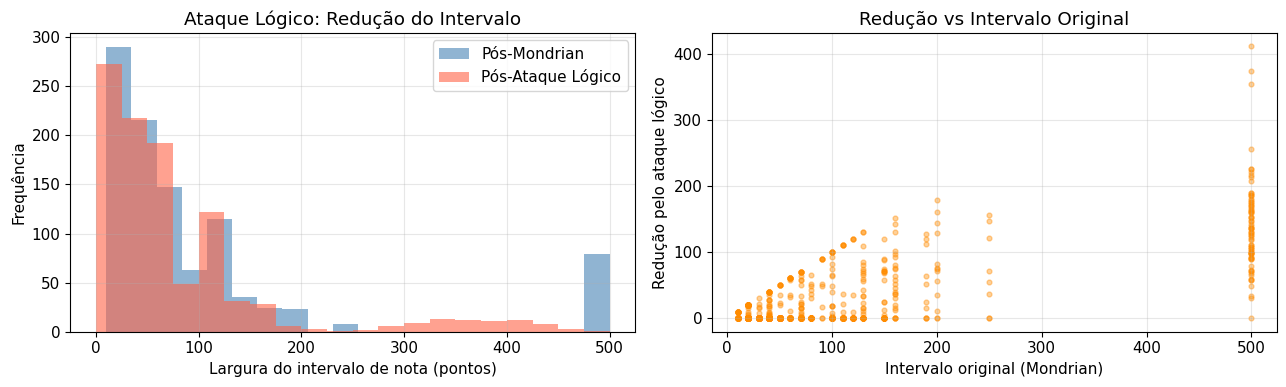

CONCLUSAO: O cruzamento de st_matricula + nu_notacorte restringe o espaço de incerteza
mesmo após a generalização Mondrian, especialmente para candidatos matriculados.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(intervalos_orig, bins=20, alpha=0.6, color='steelblue', label='Pós-Mondrian')
axes[0].hist(np.array(intervalos_orig) - reducoes, bins=20, alpha=0.6, color='tomato', label='Pós-Ataque Lógico')
axes[0].set_xlabel('Largura do intervalo de nota (pontos)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Ataque Lógico: Redução do Intervalo')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(intervalos_orig, reducoes, alpha=0.4, s=12, color='darkorange')
axes[1].set_xlabel('Intervalo original (Mondrian)')
axes[1].set_ylabel('Redução pelo ataque lógico')
axes[1].set_title('Redução vs Intervalo Original')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('CONCLUSAO: O cruzamento de st_matricula + nu_notacorte restringe o espaço de incerteza')
print('mesmo após a generalização Mondrian, especialmente para candidatos matriculados.')

### Ataque 3 - Cross-Release Temporal (Interseção T1 × T2)

**Premissa**: O Mondrian é aplicado **independentemente** sobre T1 e T2. Um adversário que observa ambos os lançamentos pode cruzar informações.

**Propriedade chave do SiSU**:
- `nu_notacorte` de T2 ≤ `nu_notacorte` de T1 para o mesmo curso (vagas sobraram, corte caiu)
- Um candidato que mudou de `NÃO APROVADO` (T1) para `APROVADO` (T2) no mesmo curso tem sua nota restringida a:
$$\text{nota} \in [\text{corte}_{T2},\ \text{corte}_{T1})$$

**Ataque**: Ao cruzar os dois recortes por curso, o adversário deriva um intervalo matematicamente preciso - quebrando a proteção que cada tabela teria isoladamente.

In [20]:
def ataque_cross_release(t1_df, t2_df):
    """
    Cruza T1 e T2 pelo identificador de curso (nome_curso + uf_campus)
    para encontrar cursos cujo nu_notacorte caiu entre chamadas.
    
    Para candidatos com status diferente entre T1 e T2 no mesmo curso:
    → Deriva intervalo exato de nota: [corte_T2, corte_T1)
    """
    # Campos necessários
    CAMPOS = ['nome_curso','uf_campus','tp_sexo','dt_nascimento','uf_origem',
              'nota_concorrencia','nu_notacorte','st_aprovado','st_matricula']
    campos_ok = [c for c in CAMPOS if c in t1_df.columns and c in t2_df.columns]

    df1 = t1_df[campos_ok].dropna(subset=['nome_curso','nu_notacorte','nota_concorrencia']).copy()
    df2 = t2_df[campos_ok].dropna(subset=['nome_curso','nu_notacorte','nota_concorrencia']).copy()

    # Nota de corte por curso em cada chamada
    corte_t1 = df1.groupby('nome_curso')['nu_notacorte'].first().rename('corte_t1')
    corte_t2 = df2.groupby('nome_curso')['nu_notacorte'].first().rename('corte_t2')
    cortes   = pd.concat([corte_t1, corte_t2], axis=1).dropna()
    cortes['delta_corte'] = cortes['corte_t1'] - cortes['corte_t2']

    # Cursos onde a nota de corte CAIU (cenário real: vagas sobraram)
    cursos_queda = cortes[cortes['delta_corte'] > 0]
    print(f'Cursos com queda de corte T1→T2: {len(cursos_queda)} de {len(cortes)} cursos em comum')
    if not cursos_queda.empty:
        print(f'  Queda média: {cursos_queda["delta_corte"].mean():.2f} pontos')
        print(f'  Queda máxima: {cursos_queda["delta_corte"].max():.2f} pontos')
        print()
        print(f'  Top 5 cursos com maior queda de corte:')
        print(cursos_queda.sort_values('delta_corte', ascending=False).head(5).to_string())
    print()

    # Para candidatos de T1 cujo curso tem queda de corte:
    # Se NÃO APROVADO em T1 → nota < corte_T1
    # Se esse mesmo candidato (por proxy de QI) fosse aprovado em T2 →
    #   nota ∈ [corte_T2, corte_T1)
    df1_neg = df1[df1['st_aprovado'] == 'N'].copy()
    df1_neg = df1_neg[df1_neg['nome_curso'].isin(cursos_queda.index)].copy()
    df1_neg = df1_neg.join(cursos_queda, on='nome_curso')

    if df1_neg.empty:
        print('Nenhum candidato de T1 (não-aprovado) encontrado em cursos com queda de corte.')
        return None

    # Intervalo derivado pelo ataque cross-release
    df1_neg['intervalo_lo'] = df1_neg['corte_t2']
    df1_neg['intervalo_hi'] = df1_neg['corte_t1']
    df1_neg['largura_cross'] = df1_neg['intervalo_hi'] - df1_neg['intervalo_lo']

    # Comparar com o intervalo que o Mondrian produziria (nota_bucket ± 10)
    df1_neg['intervalo_mondrian'] = 10   # cada bucket cobre 10 pontos

    print(f'=== Ataque Cross-Release T1xT2 ===')
    print(f'  Candidatos-alvo (nao aprovados em T1, curso com queda):  {len(df1_neg)}')
    print(f'  Largura média do intervalo cross-release: {df1_neg["largura_cross"].mean():.1f} pontos')
    print(f'  Largura do bucket Mondrian (referência) : {df1_neg["intervalo_mondrian"].mean():.1f} pontos')
    print()

    # Verificar: nota real cai dentro do intervalo derivado?
    df1_neg['nota_no_intervalo'] = (
        (df1_neg['nota_concorrencia'] >= df1_neg['intervalo_lo']) &
        (df1_neg['nota_concorrencia'] <  df1_neg['intervalo_hi'])
    )
    pct = df1_neg['nota_no_intervalo'].mean() * 100
    print(f'  Nota real dentro do intervalo cross-release: {pct:.1f}%')
    print(f'  (Confirmação empírica do poder do ataque)')
    return df1_neg

result_atk3 = ataque_cross_release(t1, t2)

Cursos com queda de corte T1→T2: 58 de 110 cursos em comum
  Queda média: 47.20 pontos
  Queda máxima: 223.84 pontos

  Top 5 cursos com maior queda de corte:
                                            corte_t1  corte_t2  delta_corte
nome_curso                                                                 
ENGENHARIA DE COMPUTAÇÃO                      839.05    615.21       223.84
ENGENHARIA DE BIOPROCESSOS E BIOTECNOLOGIA    783.84    616.23       167.61
CIÊNCIA E TECNOLOGIA                          720.23    558.61       161.62
EDUCAÇÃO FÍSICA                               783.24    646.18       137.06
ADMINISTRAÇÃO                                 701.26    592.82       108.44

=== Ataque Cross-Release T1xT2 ===
  Candidatos-alvo (nao aprovados em T1, curso com queda):  436
  Largura média do intervalo cross-release: 47.8 pontos
  Largura do bucket Mondrian (referência) : 10.0 pontos

  Nota real dentro do intervalo cross-release: 8.7%
  (Confirmação empírica do poder do ataque)


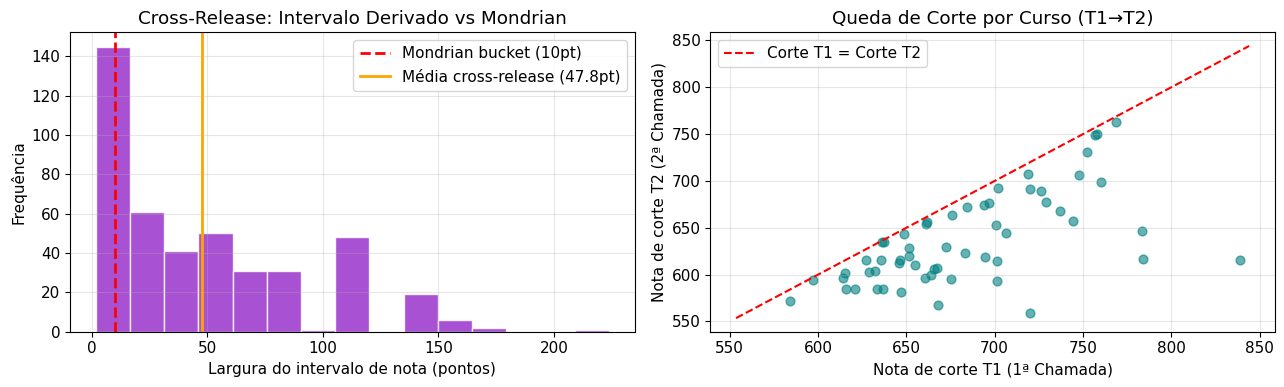

In [21]:
if result_atk3 is not None and len(result_atk3) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Distribuição das larguras de intervalo
    axes[0].hist(result_atk3['largura_cross'], bins=15, color='darkorchid', edgecolor='white', alpha=0.85)
    axes[0].axvline(10, color='red', ls='--', lw=2, label='Mondrian bucket (10pt)')
    axes[0].axvline(result_atk3['largura_cross'].mean(), color='orange', ls='-', lw=2,
                    label=f'Média cross-release ({result_atk3["largura_cross"].mean():.1f}pt)')
    axes[0].set_xlabel('Largura do intervalo de nota (pontos)')
    axes[0].set_ylabel('Frequência')
    axes[0].set_title('Cross-Release: Intervalo Derivado vs Mondrian')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Corte T1 vs Corte T2 por curso
    cortes_plot = result_atk3.groupby('nome_curso').agg(
        corte_t1=('corte_t1','first'), corte_t2=('corte_t2','first')
    ).reset_index()
    axes[1].scatter(cortes_plot['corte_t1'], cortes_plot['corte_t2'], alpha=0.6, color='teal', s=40)
    lim = [min(cortes_plot['corte_t2'].min(), cortes_plot['corte_t1'].min())-5,
           max(cortes_plot['corte_t1'].max(), cortes_plot['corte_t2'].max())+5]
    axes[1].plot(lim, lim, 'r--', lw=1.5, label='Corte T1 = Corte T2')
    axes[1].set_xlabel('Nota de corte T1 (1ª Chamada)')
    axes[1].set_ylabel('Nota de corte T2 (2ª Chamada)')
    axes[1].set_title('Queda de Corte por Curso (T1→T2)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print('Poucos dados para visualização. Aumente NROWS para observar o efeito cross-release.')

---
## Secção 9 - Conclusões

Sumário dos resultados obtidos e das vulnerabilidades demonstradas.

In [22]:
print('=' * 70)
print(' SUMÁRIO DA LINHA DE BASE - Basic Mondrian sobre SiSU 2016')
print('=' * 70)

print()
print('1. QUALIDADE DA ANONIMIZAÇÃO (NCP)')
print(f'  {"k":<6} {"NCP T1":>10} {"NCP T2":>10} {"Partições T1":>14} {"Partições T2":>14}')
print(f'  {"-"*56}')
for k in K_VALORES:
    r = resultados[k]
    print(f'  {k:<6} {r["ncp_t1"]:>9.2f}% {r["ncp_t2"]:>9.2f}% {r["nparts_t1"]:>14} {r["nparts_t2"]:>14}')

print()
print('2. VULNERABILIDADES DEMONSTRADAS')
print()
print('  Ataque 1 - Inferência Algébrica:')
atk1_pct = (result_atk1_t1['erro_abs'] < 0.01).mean() * 100
print(f'    {atk1_pct:.1f}% das notas suprimidas reconstruídas com erro < 0.01')
print(f'    Causa: nu_nota_x e nu_peso_x publicados determinam nota_concorrencia')
print(f'    Impacto: supressão de nota_concorrencia é COMPLETAMENTE INEFICAZ')

print()
print('  Ataque 2 - Inferência Lógica Intratabela:')
pct_reduz = (reducoes > 0).mean() * 100
print(f'    {pct_reduz:.1f}% dos registros têm intervalo de nota reduzido')
print(f'    Redução média: {np.mean(reducoes):.1f} pontos')
print(f'    Causa: st_matricula + nu_notacorte cria constraint lógico')
print(f'    Impacto: k-anonimato não protege contra inferência por domínio')

print()
print('  Ataque 3 - Cross-Release Temporal:')
if result_atk3 is not None and len(result_atk3) > 0:
    print(f'    Intervalo médio derivado: {result_atk3["largura_cross"].mean():.1f} pontos')
    print(f'    Mondrian bucket (referência): 10 pontos')
    pct_dentro = result_atk3['nota_no_intervalo'].mean() * 100
    print(f'    {pct_dentro:.1f}% das notas reais caem dentro do intervalo cross-release')
else:
    print('    (Aumente NROWS para observar o efeito com mais dados)')
print(f'    Causa: nu_notacorte varia entre T1 e T2; Mondrian não protege cruzamentos')
print(f'    Impacto: defesas isoladas por chamada são quebráveis por qualquer adversário')
print(f'             que aceda a ambos os lançamentos')

print()
print('3. CONCLUSÃO')
print('  A linha de base Mondrian estática demonstra que:')
print('  (a) NCP alto ≠ proteção real — vulnerabilidades algébricas/lógicas persistem')
print('  (b) Anonimização independente por lançamento não resiste a ataques temporais')
print('  (c) É necessária uma abordagem dinâmica multi-release para o SiSU')
print('=' * 70)

 SUMÁRIO DA LINHA DE BASE - Basic Mondrian sobre SiSU 2016

1. QUALIDADE DA ANONIMIZAÇÃO (NCP)
  k          NCP T1     NCP T2   Partições T1   Partições T2
  --------------------------------------------------------
  2           8.45%      7.91%            329            315
  5          31.36%     26.68%            120            126
  10         44.04%     41.99%             57             55
  25         61.13%     56.49%             19             20

2. VULNERABILIDADES DEMONSTRADAS

  Ataque 1 - Inferência Algébrica:
    100.0% das notas suprimidas reconstruídas com erro < 0.01
    Causa: nu_nota_x e nu_peso_x publicados determinam nota_concorrencia
    Impacto: supressão de nota_concorrencia é COMPLETAMENTE INEFICAZ

  Ataque 2 - Inferência Lógica Intratabela:
    31.4% dos registros têm intervalo de nota reduzido
    Redução média: 22.4 pontos
    Causa: st_matricula + nu_notacorte cria constraint lógico
    Impacto: k-anonimato não protege contra inferência por domínio

  Ataq

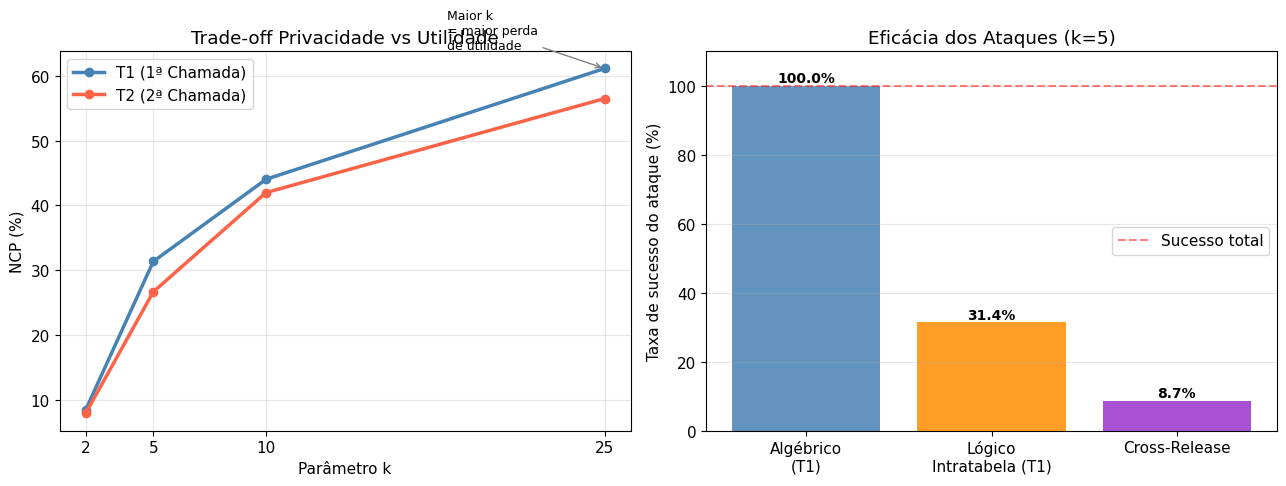

Figura salva em: baseline_mondrian_resultados.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Trade-off NCP × k
for label, ncp_list, color in [('T1 (1ª Chamada)', ncp_t1, 'steelblue'),
                                 ('T2 (2ª Chamada)', ncp_t2, 'tomato')]:
    axes[0].plot(K_VALORES, ncp_list, '-o', lw=2.5, color=color, label=label)
axes[0].set_xlabel('Parâmetro k')
axes[0].set_ylabel('NCP (%)')
axes[0].set_title('Trade-off Privacidade vs Utilidade')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(K_VALORES)
axes[0].annotate('Maior k\n= maior perda\nde utilidade', xy=(25, ncp_t1[-1]),
                  xytext=(18, ncp_t1[-1]+3), fontsize=9,
                  arrowprops=dict(arrowstyle='->', color='gray'))

# Resistência a ataques por k
k5_data = resultados[5]
ataques_labels = ['Algébrico\n(T1)', 'Lógico\nIntratabela (T1)', 'Cross-Release']
# Resistência = 1 - taxa de sucesso do ataque (simplificado)
atk1_pct_k5 = (result_atk1_t1['erro_abs'] < 0.01).mean() * 100
ataque_sucesso = [
    atk1_pct_k5,
    (reducoes > 0).mean() * 100,
    result_atk3['nota_no_intervalo'].mean() * 100 if result_atk3 is not None and len(result_atk3) > 0 else 0
]
bars = axes[1].bar(ataques_labels, ataque_sucesso, color=['steelblue','darkorange','darkorchid'], alpha=0.85)
axes[1].set_ylabel('Taxa de sucesso do ataque (%)')
axes[1].set_title(f'Eficácia dos Ataques (k=5)')
axes[1].set_ylim(0, 110)
axes[1].axhline(100, color='red', ls='--', alpha=0.5, label='Sucesso total')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, ataque_sucesso):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('baseline_mondrian_resultados.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura salva em: baseline_mondrian_resultados.png')